In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import os

from ipywidgets.widgets import Dropdown, IntSlider
from ipywidgets import interact

### Uniform Grid

In [ ]:
def generate_targets(L, Nt, t):
    '''
    Function for generating lattice target
    '''
    
    num_cells = np.sqrt(Nt)
    unit_cell_size = L/num_cells

    # Generate grid of cell indices
    cell_x, cell_y = np.meshgrid(np.arange(num_cells), np.arange(num_cells))

    # Flatten the grids and scale to unit cell size
    cell_x = cell_x.flatten() * unit_cell_size + unit_cell_size/2
    cell_y = cell_y.flatten() * unit_cell_size + unit_cell_size/2

    # Generate random offsets within each cell
    offset_x = np.random.uniform(-unit_cell_size/2, unit_cell_size/2)*int(t != 0)
    offset_y = np.random.uniform(-unit_cell_size/2, unit_cell_size/2)*int(t != 0)
    # offset_x = np.random.uniform(0, unit_cell_size)*int(t != 0)
    # offset_y = np.random.uniform(0, unit_cell_size)*int(t != 0)

    # Final point coordinates
    x = (cell_x + offset_x)%L
    y = (cell_y + offset_y)%L

    # Combine into a single array of coordinates
    points = np.column_stack((x, y))
    return points

In [ ]:
def plot_targets(Nt, t):
    L=100
    points = generate_targets(L=L, Nt=Nt, t=t)

    plt.figure(figsize =(8,8))
    plt.plot(points[:,0], points[:,1], 'ro')
    plt.setp(plt.gca(), xlim=(0,L), ylim=(0,L))
interact(plot_targets, Nt = IntSlider(min=49, max = 100, step = 1, value = 64),
                        t = IntSlider(min=0, max = 20, step=1))

interactive(children=(IntSlider(value=64, description='Nt', min=49), IntSlider(value=0, description='t', max=2…

<function __main__.plot_targets(Nt, t)>

[0.0, 100.0, 0.0, 100.0]

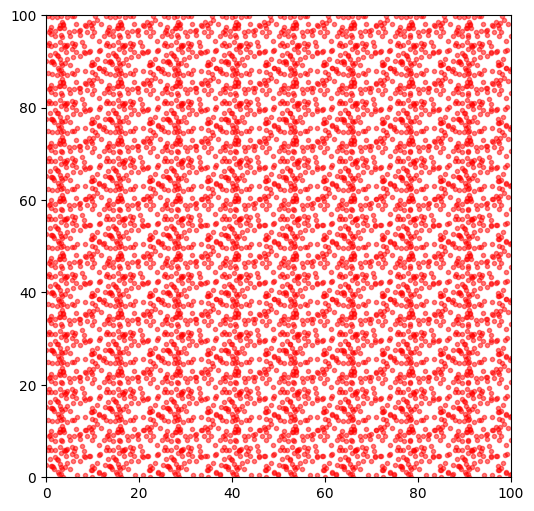

In [ ]:
plt.figure(figsize =(6,6))
for i in range(100):
    L=100
    points = generate_targets(L=L, Nt=64, t=i)
    plt.plot(points[:,0], points[:,1], 'r.', alpha= 0.5)
plt.setp(plt.gca(), xlim=(0,L), ylim=(0,L))

### Cluster Grid

In [ ]:
def large_grid(L, n_cells, n_targets, t=0):
    '''
    Function for generating clustered lattice targets
    '''

    unit_cell_size = L / n_cells

    # large checkerboard
    checker = (np.arange(n_cells)[:, None] + np.arange(n_cells)) % 2
    Nt_grid = np.where(checker == 0, n_targets[0], n_targets[1])

    all_points = []

    for i in range(n_cells):
        for j in range(n_cells):

            Nt = int(Nt_grid[i, j])

            # generate local targets inside one large cell
            pts = generate_targets(unit_cell_size, Nt, t)

            # shift to global position
            pts[:, 0] += i * unit_cell_size
            pts[:, 1] += j * unit_cell_size

            all_points.extend(pts.tolist())
    all_points = np.array(all_points)

    return all_points

In [ ]:
def plot_targets(num_cells, Nt1, Nt2, t):
    L=100
    points = large_grid(L, num_cells, [Nt1, Nt2], t = t)

    plt.figure(figsize =(8,8))
    plt.plot(points[:,0], points[:,1], 'ro')
    plt.setp(plt.gca(), xlim=(0,L), ylim=(0,L))

interact(plot_targets, 
         num_cells = IntSlider(min=0, max = 5, value =3, step = 1),  
         Nt1 = IntSlider(min=0, max = 36, step = 1, value = 16),
         Nt2 = IntSlider(min=0, max = 9, step = 1, value = 1),
         t = IntSlider(min=0, max = 20, step=1))

interactive(children=(IntSlider(value=3, description='num_cells', max=5), IntSlider(value=16, description='Nt1…

<function __main__.plot_targets(num_cells, Nt1, Nt2, t)>

[0.0, 100.0, 0.0, 100.0]

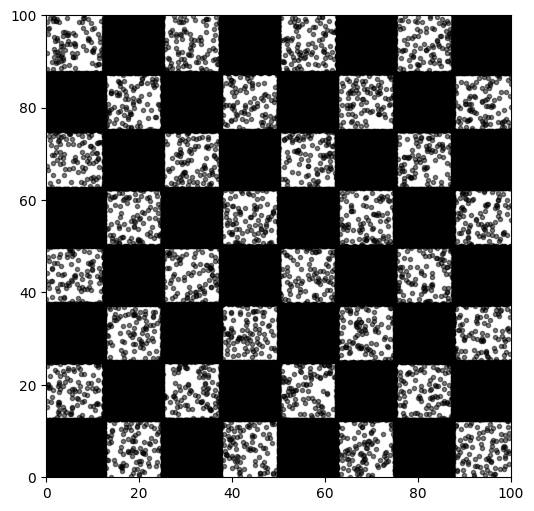

In [ ]:
plt.figure(figsize =(6,6))
for i in range(100):
    L=100
    points = large_grid(L, 8, [49, 1], t = i)
    plt.plot(points[:,0], points[:,1], 'k.', alpha= 0.5)
plt.setp(plt.gca(), xlim=(0,L), ylim=(0,L))

### NSP

In [ ]:
def generate_targets_NSP(L, Nt, n_clusters, r_cluster, t = 0, target_positions = None):

    if t==0:
        # Parent process: n_clusters parents uniformly distributed
        parent_x = np.random.uniform(0.1*L, 0.9*L, n_clusters)
        parent_y = np.random.uniform(0.1*L, 0.9*L, n_clusters)
        
        # Offspring: Nt/n_clusters targets per parent, within radius r_cluster
        offspring_per_cluster = Nt // n_clusters
        n_pts = offspring_per_cluster * n_clusters  # actual number of points (may be < Nt if not divisible)
        angles = np.random.uniform(0, 2*np.pi, n_pts)
        radii = r_cluster * np.sqrt(np.random.uniform(0, 1, n_pts))
        
        parent_idx = np.repeat(np.arange(n_clusters), offspring_per_cluster)
        x = (parent_x[parent_idx] + radii * np.cos(angles)) % L
        y = (parent_y[parent_idx] + radii * np.sin(angles)) % L

        points = np.column_stack((x, y))
    else:
        p = target_positions
        # Apply global shift (same as current, t != 0 guard preserved)
        offset_x = np.random.uniform(-r_cluster/2, r_cluster/2) * int(t != 0)*0
        offset_y = np.random.uniform(-r_cluster/2, r_cluster/2) * int(t != 0)*0
        # Final point coordinates
        x = (p[:,0] + offset_x)%L
        y = (p[:,1] + offset_y)%L

        # Combine into a single array of coordinates
        points = np.column_stack((x, y))
    
    return points


In [ ]:
def plot_targets(Nt, nc, rc, t):
    global points
    points = generate_targets_NSP(L, Nt=Nt, n_clusters=nc, 
                                r_cluster=rc, t = t, target_positions=points)

    plt.figure(figsize=(8,8))
    plt.plot(points[:,0], points[:,1], 'ro')
    plt.setp(plt.gca(), xlim=(0,L), ylim=(0,L))
    print(points.shape)

interact(plot_targets, 
         Nt=IntSlider(min=50, max=200, value=3, step=1),  
         nc=IntSlider(min=0, max=10, step=1, value=5),
         rc=IntSlider(min=1, max=10, step=1, value=3),
         t=IntSlider(min=0, max=20, step=1))

interactive(children=(IntSlider(value=50, description='Nt', max=200, min=50), IntSlider(value=5, description='…

<function __main__.plot_targets(Nt, nc, rc, t)>

### Check Target Encounter Functions

In [ ]:
def generate_targets_NSP_v2(L, Nt, n_clusters, r_cluster, t = 0, target_positions = None, index = None):

    if t==0:
        # Parent process: n_clusters parents uniformly distributed
        parent_x = np.random.uniform(0.1*L, 0.9*L, n_clusters)
        parent_y = np.random.uniform(0.1*L, 0.9*L, n_clusters)
        
        # Offspring: Nt/n_clusters targets per parent, within radius r_cluster
        offspring_per_cluster = Nt // n_clusters
        n_pts = offspring_per_cluster * n_clusters  # actual number of points (may be < Nt if not divisible)
        angles = np.random.uniform(0, 2*np.pi, n_pts)
        radii = r_cluster * np.sqrt(np.random.uniform(0, 1, n_pts))
        
        parent_idx = np.repeat(np.arange(n_clusters), offspring_per_cluster)
        x = (parent_x[parent_idx] + radii * np.cos(angles)) % L
        y = (parent_y[parent_idx] + radii * np.sin(angles)) % L

        points = np.column_stack((x, y))
    else:
        p = target_positions.copy()
        # Apply global shift (same as current, t != 0 guard preserved)
        offset_x = np.random.uniform(-r_cluster/2, r_cluster/2)
        offset_y = np.random.uniform(-r_cluster/2, r_cluster/2)
        
        for i in index:
            # Final point coordinates
            p[i,0] = (p[i,0] + offset_x)%L
            p[i,1] = (p[i,1] + offset_y)%L

        # Combine into a single array of coordinates
        points = p
    
    return points


In [ ]:
def check_inside_target_index(particle_position, target_positions, r):
    inside_target = np.linalg.norm(particle_position-target_positions, axis = 1) <= r
    inside_index = np.argwhere(inside_target == True).flatten()
    return inside_index

def plot_targets_encounter(Nt, nc, rc, t, x, y):
    global points
    enc = check_inside_target_index(np.array([x,y]), points, 2)
    
    points = generate_targets_NSP_v2(L, Nt=Nt, n_clusters=nc, 
                                r_cluster=rc, t = t, target_positions=points, index=enc)
    

    plt.figure(figsize=(8,8))
    plt.plot(points[:,0], points[:,1], 'ro')
    plt.plot(x, y, 'ko')
    plt.setp(plt.gca(), xlim=(0,L), ylim=(0,L))

interact(plot_targets_encounter, 
         Nt=IntSlider(min=50, max=200, value=3, step=1),  
         nc=IntSlider(min=0, max=10, step=1, value=5),
         rc=IntSlider(min=1, max=10, step=1, value=3),
         t=IntSlider(min=0, max=20, step=1),
         x=IntSlider(min=0, max=100, step=1, value = 50),
         y=IntSlider(min=0, max=100, step=1, value = 50))

interactive(children=(IntSlider(value=50, description='Nt', max=200, min=50), IntSlider(value=5, description='…

<function __main__.plot_targets_encounter(Nt, nc, rc, t, x, y)>